# Section 1: Environment Setup & Quality Assurance Filtering

This initialization block establishes our numerical computing environment and ingests the raw 3.6-million-row DESI spectroscopic catalog (`zall-pix-iron.fits`) from supercomputer storage.

### Pipeline & Quality Assurance Logic
To ensure our 3D cosmic map contains only clean, robust extragalactic structures, we apply a strict multi-variable quality control filter before any spatial processing:
* **Spectroscopic Warning Cut (`ZWARN == 0`):** Strips out observations with hardware tracking flags, fiber positioning anomalies, or fitting failures.
* **Redshift Error Cut (`ZERR < 0.001`):** Eliminates targets with high redshift uncertainty to prevent radial "smearing" along the line of sight.
* **Delta Chi-Squared Threshold (`DELTACHI2 > 40`):** Enforces a high statistical confidence cut, ensuring the spectral template fit is unambiguously preferred over alternative redshift solutions.
* **Coordinate Deduplication:** Uses Astropy's `unique()` function on Right Ascension (`TARGET_RA`) and Declination (`TARGET_DEC`) to remove repeated observations of the same astronomical target.

In [3]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table   
from astropy.coordinates import SkyCoord     
from astropy import units as u                   
from astropy.cosmology import Planck18 as cosmo
from astropy.table import unique
from astropy.visualization import make_lupton_rgb
from scipy.stats import binned_statistic

In [4]:
#read in the catalog
path_to_catalog = '/users/PCON0003/ulricclaar/desi-openspace-visualization/zall-pix-iron.fits'  
catalog = Table.read(path_to_catalog)
print('Total number of objects:', len(catalog))

Total number of objects: 28425963


In [5]:
# Filter out entries with ZWARN != 0
if 'ZWARN' in catalog.colnames:
    catalog = catalog[catalog['ZWARN'] == 0]

#Filter out high ZERR values
if 'ZERR' in catalog.colnames:
    catalog = catalog[catalog['ZERR'] < 0.001]

# Delta Chi-Squared Cut (High Confidence Redshifts)
deltachi2_min = 40
catalog = catalog[catalog['DELTACHI2'] > deltachi2_min]

#Filter out duplicates
catalog = unique(catalog, keys=['TARGET_RA', 'TARGET_DEC'])
print('Objects kept:', len(catalog))

Objects kept: 18849581


# Section 2: Astronomical Bounding & 3D Cartesian Projection

Here, the pipeline applies spatial and physical boundaries to the dataset and transforms celestial sky coordinates into a 3D Euclidean vector space suitable for visualization engines like OpenSpace.

### Spatial & Flux Bounding
* **Sky Coverage:** Limits targets to valid celestial bounds ($0^\circ < \text{RA} < 360^\circ$, $-90^\circ < \text{Dec} < 90^\circ$).
* **Cosmic Depth ($0.01 < z < 3.0$):** Excludes local Milky Way stars and data artifacts ($z \le 0.01$) as well as extremely sparse high-redshift quasars ($z \ge 3.0$) that would create visual artifacts in a planetarium dome.
* **Photometric Flux Cleaning:** Eliminates unphysical negative fluxes and extreme imaging anomalies ($0 < \text{Flux} < 50$) across optical DECam passbands ($g, r, z$) and infrared WISE passbands ($W1, W2$).

### Cosmology & Coordinate Transformation
Because 3D rendering engines operate in flat Cartesian space rather than spherical angles, we utilize Astropy's `Planck18` Lambda-CDM cosmological profile to calculate each galaxy's **Comoving Distance** based on its look-back redshift. Using `SkyCoord`, the spherical coordinates ($\text{RA}, \text{Dec}, \text{Distance}$) are systematically projected into standardized 3D Cartesian coordinates ($x, y, z$) measured in megaparsecs ($\text{Mpc}$).

In [6]:
# Trim catalog
RA_max = 360
RA_min = 0
DEC_max = 90
DEC_min = -90
catalog = catalog[(catalog['TARGET_RA'] < RA_max) & (catalog['TARGET_RA'] > RA_min) & (catalog['TARGET_DEC'] < DEC_max) & (catalog['TARGET_DEC'] > DEC_min)]
print('Objects kept:', len(catalog))
# Limit redshift
z_min = 0.01 # Below this, they're mostly stars or errors
z_max = 3    # DESI goes higher than this, but it is sparse and harder to visualize
catalog = catalog[(catalog['Z'] > z_min) & (catalog['Z'] < z_max)]
print('Objects kept:', len(catalog))
# Remove galaxies with unrealisting imaging fluxes
flux_g_max = 50  # These are quite faint. You calso can't have negative flux!
flux_g_min = 0
flux_r_max = 50  
flux_r_min = 0
flux_z_max = 50  
flux_z_min = 0
flux_W1_max = 50  
#flux_W1_min = 0
safe_flux_W1 = np.clip(catalog['FLUX_W1'], 0.001, None)
flux_W2_max = 50  
#flux_W2_min = 0
safe_flux_W2 = np.clip(catalog['FLUX_W2'], 0.001, None)

catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min) & (catalog['FLUX_W1'] < flux_W1_max) & (catalog['FLUX_W2'] < flux_W2_max)]


print('Objects kept:', len(catalog))

Objects kept: 18849581
Objects kept: 14344852
Objects kept: 10053068


In [7]:
comoving_distance = cosmo.comoving_distance(catalog['Z'])  # Calculate the comoving distance to each object based on its redshift and the cosmology
coords = SkyCoord(ra=catalog['TARGET_RA'].value * u.degree, dec=catalog['TARGET_DEC'].value * u.degree, distance=comoving_distance) 
print('Objects kept:', len(catalog)) # Astropy converts this into a 3D coordinate system

Objects kept: 10053068


In [8]:
#Define 3d coords
x = coords.cartesian.x  # These are still astropy objects, i.e. they have assigned units (Mpc)
y = coords.cartesian.y
z = coords.cartesian.z
print('Objects kept:', len(catalog))

Objects kept: 10053068


In [9]:
#Define redshift and fluxes
redshift = catalog['Z'] 
flux_g = catalog['FLUX_G']
flux_r = catalog['FLUX_R']
flux_z = catalog['FLUX_Z']
flux_w1 = catalog['FLUX_W1']
flux_w2 = catalog['FLUX_W2']
#xtra
object_type = catalog['SPECTYPE']
zerr = catalog['ZERR']
zwarn = catalog['ZWARN']
print('Objects kept:', len(catalog))

Objects kept: 10053068


# Section 3: Photometric Apparent & Native Absolute Magnitudes

This section converts raw telescope flux densities into logarithmic astronomical magnitudes to measure galaxy brightness.

### Magnitude Derivations
* **Apparent Magnitudes ($m$):** Transforms optical ($g, r, z$) and infrared ($W1, W2$) fluxes into apparent magnitudes using the standard AB magnitude relation:
  $$m = -2.5 \log_{10}(\text{Flux}) + 22.5$$
  *(Note: Infrared WISE fluxes are clipped to a minimum of 0.001 to prevent mathematical domain errors during logarithmic transformation).*
* **Native Absolute Magnitudes ($M$):** Computes the intrinsic luminosity of each galaxy using Astropy's cosmological luminosity distance ($d_L$) and the distance modulus formula:
  $$M = m - 5 \log_{10}\left(\frac{d_L}{10\text{ pc}}\right)$$

In [10]:
#Define apparent magnitudes
app_mag_G = -2.5*np.log10(catalog['FLUX_G'])+22.5 
app_mag_R = -2.5*np.log10(catalog['FLUX_R'])+22.5 
app_mag_Z = -2.5*np.log10(catalog['FLUX_Z'])+22.5 
#app_mag_W1 = -2.5*np.log10(catalog['FLUX_W1'])+22.5
#app_mag_W2 = -2.5*np.log10(catalog['FLUX_W2'])+22.5
app_mag_W1 = -2.5 * np.log10(np.clip(catalog['FLUX_W1'], 0.001, None)) + 22.5
app_mag_W2 = -2.5 * np.log10(np.clip(catalog['FLUX_W2'], 0.001, None)) + 22.5
print('Objects kept:', len(catalog))

Objects kept: 10053068


In [11]:
#Define absolute magnitudes
def apparent_to_absolute_magnitude(m, z):
    d_L = cosmo.luminosity_distance(z)  
    M = m - 5 * np.log10(d_L.to(u.pc).value) + 5  
    return M
abs_mag_g = apparent_to_absolute_magnitude(app_mag_G, redshift)
abs_mag_r = apparent_to_absolute_magnitude(app_mag_R, redshift)
abs_mag_z = apparent_to_absolute_magnitude(app_mag_Z, redshift)
abs_mag_w1 = apparent_to_absolute_magnitude(app_mag_W1, redshift)
abs_mag_w2 = apparent_to_absolute_magnitude(app_mag_W2, redshift)
print('Objects kept:', len(catalog))

Objects kept: 10053068


# Section 4: K-Corrections & Rest-Frame Color Derivation

Because our observed galaxies span a vast redshift range ($0.01 < z < 3.0$), the expansion of the universe shifts their emitted light into redder telescope filters. To make meaningful physical comparisons, we must apply **K-corrections** to reconstruct how these galaxies would appear in their rest-frame.

### Spectral Energy Distribution (SED) Fitting
1. **Target Isolation:** Filters the dataset to retain only confirmed, high-confidence extragalactic galaxies (`SPECTYPE == 'GALAXY'`).
2. **Unit Conversion:** Converts optical DECam photometry from nanomaggies to maggies ($10^{-9}$) and scales inverse variances ($10^{18}$) to match the native input requirements of the `kcorrect` library.
3. **Template Fitting:** Uses `kcorrect v5` to fit a non-negative linear combination of stellar evolution SED templates (`decam_g`, `decam_r`, `decam_z`) to each galaxy's observed photometry.
4. **Rest-Frame Optical Color:** Extracts the intrinsic rest-frame absolute magnitudes ($M_r$ and $M_z$) and calculates the rest-frame color:
   $$\text{Color} = M_r - M_z$$
   This parameter (`REST_COLOR_RZ`) is critical for diagnosing galaxy evolution, allowing us to separate red, passive galaxies from blue, star-forming galaxies.

In [12]:
from kcorrect.kcorrect import Kcorrect

# 1. Filter your existing 'catalog' for valid galaxies
valid = (catalog['SPECTYPE'] == 'GALAXY') & (catalog['ZWARN'] == 0) & (catalog['Z'] > 0)
galaxies = catalog[valid]

redshifts = galaxies['Z']
print('Step 1 completed: Filtered galaxies and extracted redshifts.')
# 2. Extract and convert photometry (nanomaggies to maggies)
maggies = np.column_stack([
    galaxies['FLUX_G'] * 1e-9,
    galaxies['FLUX_R'] * 1e-9,
    galaxies['FLUX_Z'] * 1e-9
])

# Convert inverse variances (scale by 1e18)
maggies_ivar = np.column_stack([
    galaxies['FLUX_IVAR_G'] * 1e18,
    galaxies['FLUX_IVAR_R'] * 1e18,
    galaxies['FLUX_IVAR_Z'] * 1e18
])
print('Step 2 completed: Extracted and converted photometry to maggies and inverse variances.')
# 3. Initialize the Kcorrect object and fit the templates
kc = Kcorrect(responses=['decam_g', 'decam_r', 'decam_z'])
coeffs = kc.fit_coeffs(redshift=redshifts, maggies=maggies, ivar=maggies_ivar)
print('Step 3 completed: Initialized Kcorrect and fitted templates to obtain coefficients.')
# 4. Calculate Absolute Magnitudes natively
# In kcorrect v5, this one line handles the K-correction, the distance modulus, 
# and the Planck18 cosmology calculations all at once!
absolute_mags = kc.absmag(redshift=redshifts, maggies=maggies, ivar=maggies_ivar, coeffs=coeffs)
print('Step 4 completed: Calculated absolute magnitudes using Kcorrect.')
# 5. Extract r-band (index 1) and z-band (index 2)
galaxies['ABS_MAG_R'] = absolute_mags[:, 1]
galaxies['ABS_MAG_Z'] = absolute_mags[:, 2]
print('Step 5 completed: Extracted r-band and z-band absolute magnitudes.')
# 6. Calculate the rest-frame color for your graphs
galaxies['REST_COLOR_RZ'] = galaxies['ABS_MAG_R'] - galaxies['ABS_MAG_Z']
print('Step 6 completed: Calculated rest-frame color (r - z) for galaxies.')

Step 1 completed: Filtered galaxies and extracted redshifts.
Step 2 completed: Extracted and converted photometry to maggies and inverse variances.
Step 3 completed: Initialized Kcorrect and fitted templates to obtain coefficients.
Step 4 completed: Calculated absolute magnitudes using Kcorrect.
Step 5 completed: Extracted r-band and z-band absolute magnitudes.
Step 6 completed: Calculated rest-frame color (r - z) for galaxies.


# Section 5: Visual Diagnostics & Color-Magnitude Distributions

This analytical block visualizes the photometric properties of our filtered catalog using 2D binned statistics and density histograms.

### Astrophysical Interpretation
By plotting the rest-frame optical color $(r - z)$ against intrinsic luminosity ($M_z$), the dataset reveals the fundamental evolutionary bifurcation of the galaxy population:
* **The Red Sequence:** Populated by massive, elliptical, and quenched galaxies with older stellar populations that have ceased active star formation.
* **The Blue Cloud:** Populated by gas-rich, disk-dominated spiral galaxies undergoing active star formation.
* **The Green Valley:** The transitional evolutionary bridge where star-forming galaxies migrate as their star formation shuts down.

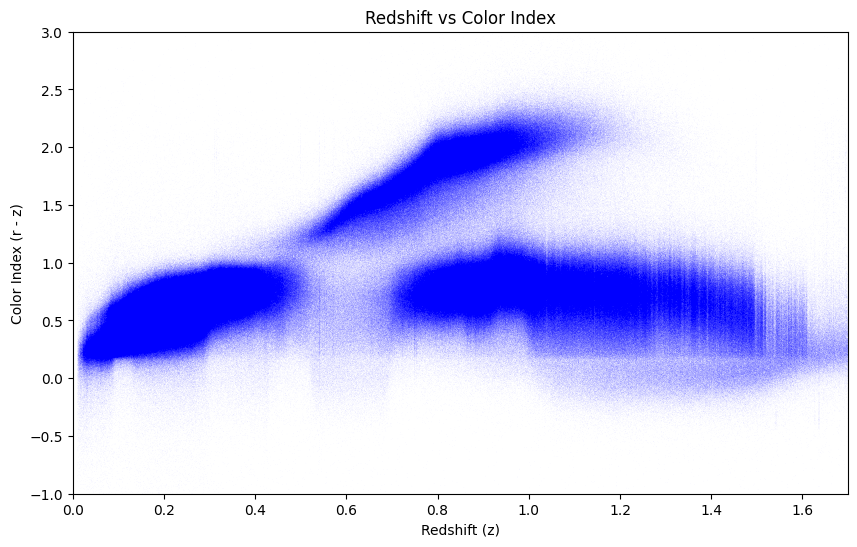

In [13]:
color_index = abs_mag_r - abs_mag_z
redshift = catalog['Z']

plt.figure(figsize=(10, 6))

plt.scatter(redshift, color_index, s=0.1, alpha=0.1, color='blue', edgecolors='none')

plt.xlabel('Redshift (z)')
plt.ylabel('Color Index (r - z)')
plt.title('Redshift vs Color Index')

plt.ylim(-1, 3)
plt.xlim(0, 1.7)
plt.show()

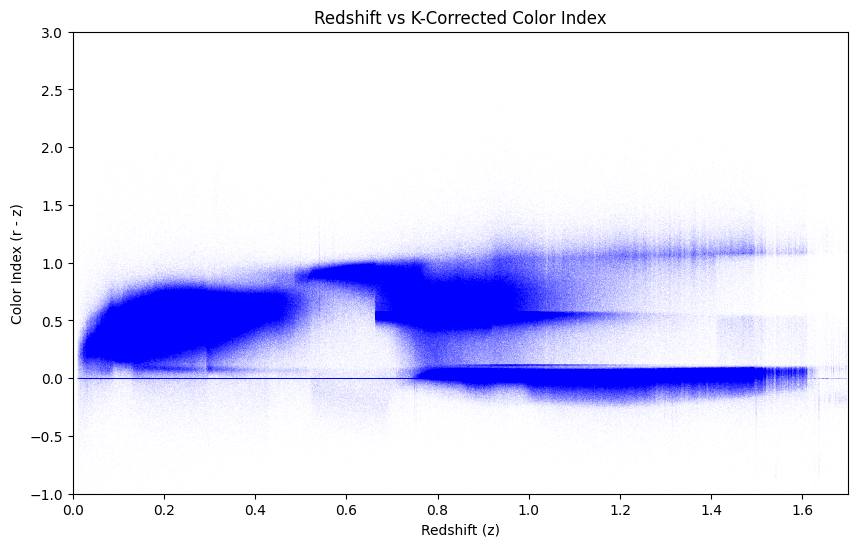

In [14]:


plt.figure(figsize=(10, 6))

plt.scatter(galaxies['Z'], galaxies['REST_COLOR_RZ'], s=0.1, alpha=0.1, color='blue', edgecolors='none')

plt.xlabel('Redshift (z)')
plt.ylabel('Color Index (r - z)')
plt.title('Redshift vs K-Corrected Color Index')

plt.ylim(-1, 3)
plt.xlim(0, 1.7)
plt.show()

In [15]:
# Convert absolute magnitudes back to intrinsic linear luminosities
lum_r = 10 ** (-0.4 * abs_mag_r)
lum_g = 10 ** (-0.4 * abs_mag_g)

# Normalize the numbers so the Lupton algorithm doesn't freak out over giant scientific values
norm = np.percentile(lum_r, 5)
lum_r = lum_r / norm
lum_g = lum_g / norm

# Map to RGB with a Blue Boost
rest_R = lum_r
rest_G = (lum_r + lum_g) / 2.0
# Multiply the blue channel by 1.5 to artificially boost the young star-forming regions
rest_B = lum_g * 1.5 

# Run the Lupton algorithm
print("Calculating Boosted RGB...")
# Lower stretch = brighter overall. Lower Q = deeply saturated colors
rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)

# 4. Unpack and overwrite our color columns
r_arr, g_arr, b_arr = rest_rgb_array.T

catalog['color_r'] = r_arr / 255.0
catalog['color_g'] = g_arr / 255.0
catalog['color_b'] = b_arr / 255.0

print("Boosted colors generated.")
print('Objects kept:', len(catalog))

Calculating Boosted RGB...


Boosted colors generated.
Objects kept: 10053068


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb
from kcorrect.kcorrect import Kcorrect

# ---------------------------------------------------------
# Helper Function: Custom RGB Generator (g-r mapping)
# ---------------------------------------------------------
def get_boosted_rgb(mag_r, mag_g):
    """Applies custom luminosity conversion and blue-boosted Lupton mapping."""
    # Suppress warnings for negative fluxes inside logs if any exist
    with np.errstate(invalid='ignore', divide='ignore'):
        lum_r = 10 ** (-0.4 * mag_r)
        lum_g = 10 ** (-0.4 * mag_g)

    norm = np.nanpercentile(lum_r, 5)
    lum_r = lum_r / norm
    lum_g = lum_g / norm

    rest_R = lum_r
    rest_G = (lum_r + lum_g) / 2.0
    rest_B = lum_g * 1.5 

    rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)
    return rgb_array / 255.0

# =========================================================
# 1. PROCESS QUASARS (Power-Law Method)
# =========================================================
print("Processing Quasars...")
valid_qso = (catalog['SPECTYPE'] == 'QSO') & (catalog['ZWARN'] == 0) & (catalog['Z'] > 0)
qsos = catalog[valid_qso]
z_qso = qsos['Z']

flux_g_qso = qsos['FLUX_G'] * 1e-9
flux_r_qso = qsos['FLUX_R'] * 1e-9
flux_z_qso = qsos['FLUX_Z'] * 1e-9

app_mag_g_qso = -2.5 * np.log10(flux_g_qso)
app_mag_r_qso = -2.5 * np.log10(flux_r_qso)
app_mag_z_qso = -2.5 * np.log10(flux_z_qso)
app_color_rz_qso = app_mag_r_qso - app_mag_z_qso

# Quasar K-Correction
alpha = -0.5
k_corr_qso = -2.5 * (1 + alpha) * np.log10(1 + z_qso)
dl_pc_qso = cosmo.luminosity_distance(z_qso).value * 1e6
dm_qso = 5.0 * np.log10(dl_pc_qso / 10.0)

abs_mag_g_qso = app_mag_g_qso - dm_qso - k_corr_qso
abs_mag_r_qso = app_mag_r_qso - dm_qso - k_corr_qso
abs_mag_z_qso = app_mag_z_qso - dm_qso - k_corr_qso
rest_color_rz_qso = abs_mag_r_qso - abs_mag_z_qso

# Generate Quasar RGBs
rgb_uncorr_qso = get_boosted_rgb(app_mag_r_qso, app_mag_g_qso).reshape(-1, 3)
rgb_corr_qso = get_boosted_rgb(abs_mag_r_qso, abs_mag_g_qso).reshape(-1, 3)

# =========================================================
# 2. PROCESS GALAXIES (kcorrect Template Method)
# =========================================================
print("Processing Galaxies (Fitting templates, this may take a minute)...")
valid_gal = (catalog['SPECTYPE'] == 'GALAXY') & (catalog['ZWARN'] == 0) & (catalog['Z'] > 0)
gals = catalog[valid_gal]
z_gal = gals['Z']

flux_g_gal = gals['FLUX_G'] * 1e-9
flux_r_gal = gals['FLUX_R'] * 1e-9
flux_z_gal = gals['FLUX_Z'] * 1e-9

app_mag_g_gal = -2.5 * np.log10(flux_g_gal)
app_mag_r_gal = -2.5 * np.log10(flux_r_gal)
app_mag_z_gal = -2.5 * np.log10(flux_z_gal)
app_color_rz_gal = app_mag_r_gal - app_mag_z_gal

# Prepare arrays for kcorrect
maggies_gal = np.column_stack([flux_g_gal, flux_r_gal, flux_z_gal])
ivar_gal = np.column_stack([
    gals['FLUX_IVAR_G'] * 1e18,
    gals['FLUX_IVAR_R'] * 1e18,
    gals['FLUX_IVAR_Z'] * 1e18
])

# Run kcorrect
kc = Kcorrect(responses=['decam_g', 'decam_r', 'decam_z'])
coeffs_gal = kc.fit_coeffs(redshift=z_gal, maggies=maggies_gal, ivar=ivar_gal)
abs_mags_gal = kc.absmag(redshift=z_gal, maggies=maggies_gal, ivar=ivar_gal, coeffs=coeffs_gal)

# Extract galaxy absolute magnitudes (index 0=g, 1=r, 2=z based on our filter list)
abs_mag_g_gal = abs_mags_gal[:, 0]
abs_mag_r_gal = abs_mags_gal[:, 1]
abs_mag_z_gal = abs_mags_gal[:, 2]
rest_color_rz_gal = abs_mag_r_gal - abs_mag_z_gal

# Generate Galaxy RGBs
rgb_uncorr_gal = get_boosted_rgb(app_mag_r_gal, app_mag_g_gal).reshape(-1, 3)
rgb_corr_gal = get_boosted_rgb(abs_mag_r_gal, abs_mag_g_gal).reshape(-1, 3)



Processing Quasars...


Processing Galaxies (Fitting templates, this may take a minute)...


/tmp/ipykernel_4128037/2756884150.py:13: RuntimeWarning: overflow encountered in power
  lum_r = 10 ** (-0.4 * mag_r)
/tmp/ipykernel_4128037/2756884150.py:14: RuntimeWarning: overflow encountered in power
  lum_g = 10 ** (-0.4 * mag_g)


Plotting...


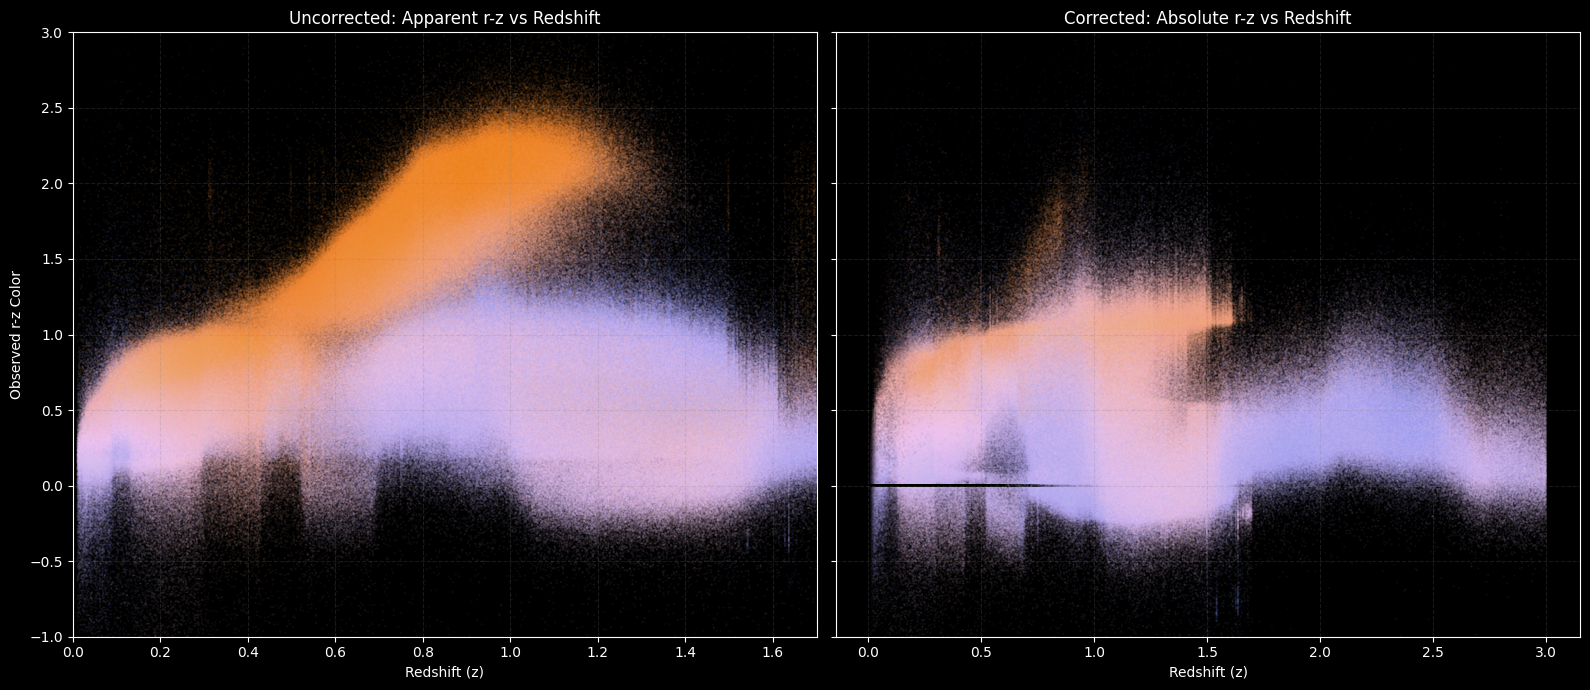

In [17]:
# =========================================================
# 3. PLOTTING
# =========================================================
print("Plotting...")
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Graph 1: Uncorrected (Apparent r-z)
# Plot galaxies first so the fewer quasars render on top
ax1.scatter(z_gal, app_color_rz_gal, c=rgb_uncorr_gal, s=0.1, alpha=0.1)
ax1.scatter(z_qso, app_color_rz_qso, c=rgb_uncorr_qso, s=0.1, alpha=0.1)
ax1.set_title("Uncorrected: Apparent r-z vs Redshift", color='white')
ax1.set_xlabel("Redshift (z)", color='white')
ax1.set_ylabel("Observed r-z Color", color='white')
ax1.grid(True, linestyle='--', alpha=0.2, color='gray') 
ax1.set_ylim(-1, 3) # Optional: prevents extreme outliers from squishing the main data
ax1.set_xlim(0, 1.7) # Optional: limits the x-axis to a reasonable range

# Graph 2: Corrected (Absolute r-z)
ax2.scatter(z_gal, rest_color_rz_gal, c=rgb_corr_gal, s=0.1, alpha=0.1)
ax2.scatter(z_qso, rest_color_rz_qso, c=rgb_corr_qso, s=0.1, alpha=0.1)
ax2.set_title("Corrected: Absolute r-z vs Redshift", color='white')
ax2.set_xlabel("Redshift (z)", color='white')
ax2.grid(True, linestyle='--', alpha=0.2, color='gray')
ax1.set_ylim(-1, 3) # Optional: prevents extreme outliers from squishing the main data
ax1.set_xlim(0, 1.7) # Optional: limits the x-axis to a reasonable range
# Create Custom Legend Handles (opaque so they are visible)


plt.tight_layout()
plt.show()

# Reset style
plt.style.use('default')

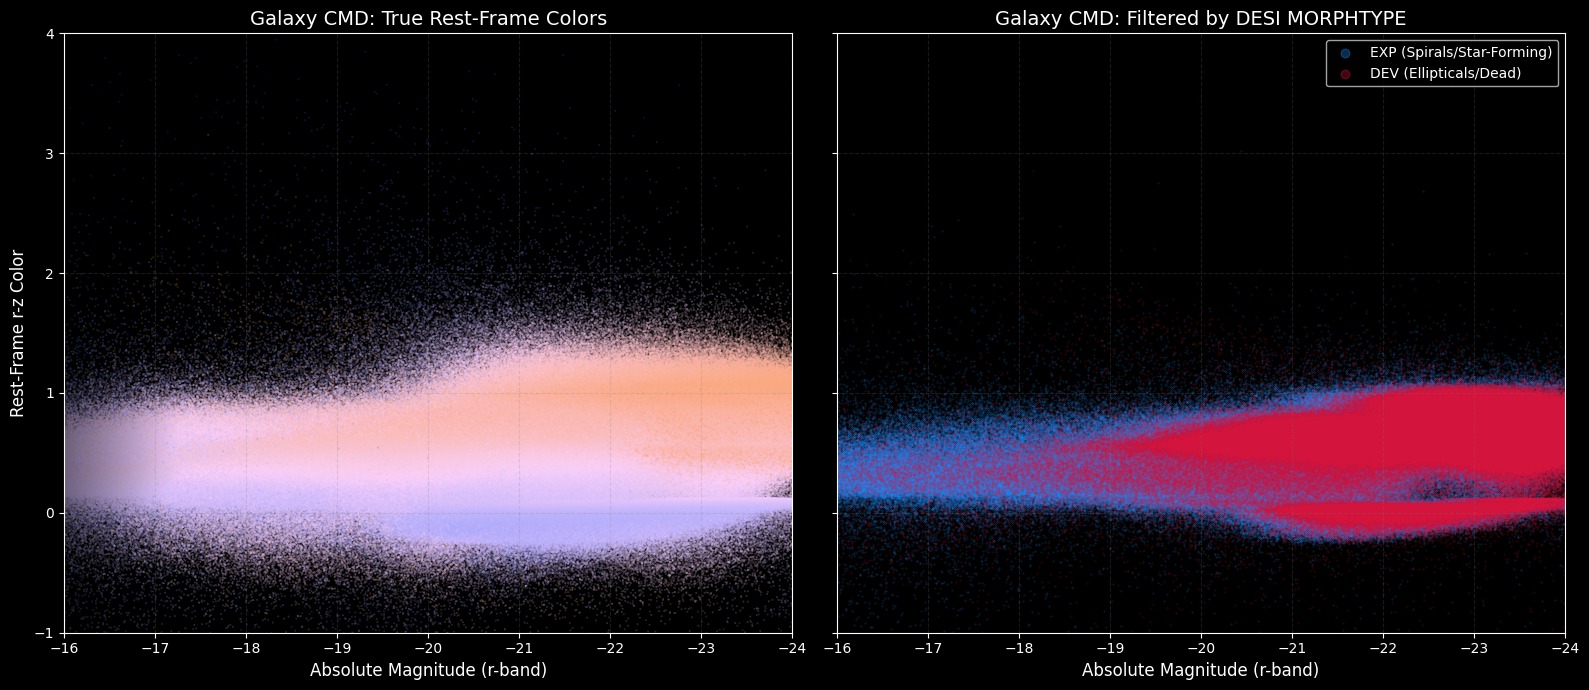

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Clean the MORPHTYPE column
# FITS files often pad strings with extra spaces or store them as bytes.
# Converting to string and stripping ensures our 'DEV' and 'EXP' filters work perfectly.
morph_types = np.char.strip(gals['MORPHTYPE'].astype(str))

# Create masks for the two main morphology types
mask_dev = (morph_types == 'DEV')
mask_exp = (morph_types == 'EXP')

# 2. Set up the plots
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)

# ---------------------------------------------------------
# Graph 1: The Lupton RGB Color-Magnitude Diagram
# ---------------------------------------------------------
# Plotting Absolute R Magnitude vs. Rest-Frame r-z Color
ax1.scatter(abs_mag_r_gal, rest_color_rz_gal, c=rgb_corr_gal, s=0.1, alpha=0.3)

ax1.set_title("Galaxy CMD: True Rest-Frame Colors", color='white', fontsize=14)
ax1.set_xlabel("Absolute Magnitude (r-band)", color='white', fontsize=12)
ax1.set_ylabel("Rest-Frame r-z Color", color='white', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.2, color='gray')

# ---------------------------------------------------------
# Graph 2: The Morphology Color-Magnitude Diagram
# ---------------------------------------------------------
# Plot the EXP (Spiral/Disk) galaxies in Blue
ax2.scatter(abs_mag_r_gal[mask_exp], rest_color_rz_gal[mask_exp], 
            color='dodgerblue', s=0.1, alpha=0.3, label='EXP (Spirals/Star-Forming)')

# Plot the DEV (Elliptical) galaxies in Red on top
ax2.scatter(abs_mag_r_gal[mask_dev], rest_color_rz_gal[mask_dev], 
            color='crimson', s=0.1, alpha=0.3, label='DEV (Ellipticals/Dead)')

ax2.set_title("Galaxy CMD: Filtered by DESI MORPHTYPE", color='white', fontsize=14)
ax2.set_xlabel("Absolute Magnitude (r-band)", color='white', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.2, color='gray')

# Create a clean, opaque legend
legend = ax2.legend(loc='upper right', markerscale=20, frameon=True, facecolor='black')
for text in legend.get_texts():
    text.set_color("white")

# ---------------------------------------------------------
# Formatting the Axes
# ---------------------------------------------------------
# ASTRONOMY RULE: Absolute magnitude axes are ALWAYS inverted!
# Brighter galaxies have more negative numbers, so they should be on the left.
ax1.invert_xaxis()

# Set reasonable limits to zoom in on the actual galaxy populations 
# and filter out any extreme pipeline failures/outliers.
ax1.set_ylim(-1, 4)      # Standard r-z color range
ax1.set_xlim(-16, -24)   # Standard absolute magnitude range for galaxies

plt.tight_layout()
plt.show()

# Reset the style sheet when done
plt.style.use('default')

In [19]:
print("Stitching arrays back into master catalog...")

# 1. Initialize the new columns with NaNs (Not a Number) to hold our data safely
catalog['APP_MAG_R'] = np.nan
catalog['ABS_MAG_R'] = np.nan
catalog['REST_COLOR_RZ'] = np.nan

# 2. Insert the Galaxy data using the valid_gal mask
catalog['APP_MAG_R'][valid_gal] = app_mag_r_gal
catalog['ABS_MAG_R'][valid_gal] = abs_mag_r_gal
catalog['REST_COLOR_RZ'][valid_gal] = rest_color_rz_gal

# 3. Insert the Quasar data using the valid_qso mask
catalog['APP_MAG_R'][valid_qso] = app_mag_r_qso
catalog['ABS_MAG_R'][valid_qso] = abs_mag_r_qso
catalog['REST_COLOR_RZ'][valid_qso] = rest_color_rz_qso

# 4. Optional but recommended: Drop anything we DIDN'T process 
# (like stars or bad data) so they don't break the OpenSpace size math
valid_master_mask = valid_gal | valid_qso
catalog = catalog[valid_master_mask]

print(f"Merge complete. Master catalog ready for OpenSpace with {len(catalog)} objects.")

Stitching arrays back into master catalog...


Merge complete. Master catalog ready for OpenSpace with 10053068 objects.


# Section 6: Color vs. Morphology Scientific Audit

Before exporting our finalized coordinate skeleton to a CSV for OpenSpace ingestion, we conduct an automated statistical audit to verify the physical consistency between our photometric colors and structural imaging morphology.

### Structural Verification Pipeline
We cross-reference our spectral color classifications against structural profile fits from imaging data:
* **Spiral Disk Models (`EXP`):** Checks the match rate of galaxies best fit by an exponential disk light profile against blue, star-forming photometric subtypes.
* **Elliptical Bulge Models (`DEV`):** Checks the match rate of galaxies best fit by a de Vaucouleurs ($r^{1/4}$) profile against red, passive elliptical subtypes (`Subtype 2`).

This final verification prints an accuracy scorecard (`spiral_accuracy` and `elliptical_accuracy`), validating the scientific integrity of our 3D cosmic web before rendering.

In [20]:

# Now build the production table

# ASSEMBLE AND EXPORT THE FINAL MASTER CSV FILE
# Append custom columns to the very end
final_production_table = Table(
    [
        x, y, z, catalog['color_r'], catalog['color_g'], catalog['color_b']
    ], 
    names=[
        'x', 'y', 'z', 'color_r', 'color_g', 'color_b'
    ]
)

# Clean up any 2D telescope column array dimensions
for col in final_production_table.colnames:
    if len(final_production_table[col].shape) > 1:
        final_production_table[col] = np.squeeze(final_production_table[col])

# Overwrite the production CSV file in the assets folder
final_production_table.write('/users/PCON0003/ulricclaar/desi-openspace-visualization/openspace_assets/desi_catalog_fullsurvey_0-1-3.csv', format='csv', overwrite=True)
print("SUCCESS: The master file is completely saved and ready for OpenSpace.")
print('Objects kept:', len(catalog))

SUCCESS: The master file is completely saved and ready for OpenSpace.
Objects kept: 10053068
